# Model 1 - 사고 발생 분류 모델

모델 1은 전체 포인트에 대해 `사고발생 = 1 if 위험도 > 0 else 0`을 예측하는 분류 모델입니다.

- 입력: 전처리된 환경 feature
- 라벨: `위험도 > 0`에서 파생한 `사고발생`
- 출력: `사고발생확률 = P(위험도 > 0 | x)`
- 평가: threshold 지표와 Precision@K / Recall@K / F1@K

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd

# 노트북을 프로젝트 루트 또는 notebooks 폴더 어디서 실행해도 경로가 맞도록 처리합니다.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

VENV_PYTHON = PROJECT_ROOT / ".venv" / "bin" / "python"
PYTHON = VENV_PYTHON if VENV_PYTHON.exists() else Path(sys.executable)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PYTHON: {PYTHON}")

PROJECT_ROOT: /home/huichan/SPARV/SilverWalk
PYTHON: /home/huichan/SPARV/SilverWalk/.venv/bin/python


In [2]:
def make_tensorflow_env() -> dict[str, str]:
    """TensorFlow subprocess가 pip NVIDIA CUDA 라이브러리를 찾도록 환경변수를 구성합니다."""
    env = os.environ.copy()
    site_packages_candidates = list((PROJECT_ROOT / ".venv" / "lib").glob("python*/site-packages"))
    nvidia_lib_dirs = []
    for site_packages in site_packages_candidates:
        nvidia_root = site_packages / "nvidia"
        if nvidia_root.exists():
            nvidia_lib_dirs.extend(str(path) for path in nvidia_root.rglob("lib") if path.is_dir())

    existing_ld_path = env.get("LD_LIBRARY_PATH", "")
    ld_parts = [*nvidia_lib_dirs, "/usr/lib/wsl/lib"]
    if existing_ld_path:
        ld_parts.append(existing_ld_path)
    env["LD_LIBRARY_PATH"] = ":".join(dict.fromkeys(part for part in ld_parts if part))
    return env


tensorflow_env = make_tensorflow_env()
gpu_check_code = """
import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('Physical GPUs:', gpus)
if gpus:
    print('GPU를 사용할 수 있습니다.')
else:
    print('GPU를 사용할 수 없습니다. CPU로 실행됩니다.')
"""

result = subprocess.run(
    [str(PYTHON), "-c", gpu_check_code],
    cwd=PROJECT_ROOT,
    env=tensorflow_env,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode != 0:
    raise RuntimeError("TensorFlow GPU 확인 subprocess가 실패했습니다.")

TensorFlow: 2.21.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU를 사용할 수 있습니다.

I0000 00:00:1780730064.936698   49958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780730064.975469   49958 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780730065.826072   49958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE

In [3]:
required_paths = {
    "train": PROJECT_ROOT / "data" / "processed" / "original_train_train_preprocessed.csv",
    "val": PROJECT_ROOT / "data" / "processed" / "original_train_val_preprocessed.csv",
    "test": PROJECT_ROOT / "data" / "processed" / "original_train_test_preprocessed.csv",
    "preprocess_config": PROJECT_ROOT / "artifacts" / "preprocessors" / "original_train_preprocess_config.json",
    "train_script": PROJECT_ROOT / "scripts" / "train" / "train_accident_classifier.py",
}

path_status = []
for name, path in required_paths.items():
    path_status.append(
        {
            "name": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else None,
        }
    )

path_status_frame = pd.DataFrame(path_status)
display(path_status_frame)

missing = [row["path"] for row in path_status if not row["exists"]]
if missing:
    raise FileNotFoundError(f"필수 파일이 없습니다: {missing}")

,name,path,exists,size_mb
0,train,data/processed/original_train_train_preprocess...,True,592.13
1,val,data/processed/original_train_val_preprocessed...,True,126.88
2,test,data/processed/original_train_test_preprocesse...,True,126.90
3,preprocess_config,artifacts/preprocessors/original_train_preproc...,True,0.02
4,train_script,scripts/train/train_accident_classifier.py,True,0.01


In [4]:
# 학습 설정입니다. 빠른 테스트가 필요하면 LIMIT_ROWS 값을 5000 정도로 지정하십시오.
RUN_NAME = "mlp_accident_classifier_notebook"
EPOCHS = 100
BATCH_SIZE = 1024
DEVICE = "auto"  # "auto", "gpu", "cpu"
THRESHOLD = 0.5
TOP_K = [100, 300, 500, 700, 1000]
LIMIT_ROWS = None  # 예: 5000

model_path = PROJECT_ROOT / "artifacts" / "models" / f"{RUN_NAME}.keras"
metrics_path = PROJECT_ROOT / "artifacts" / "reports" / f"{RUN_NAME}_metrics.json"
history_path = PROJECT_ROOT / "artifacts" / "reports" / f"{RUN_NAME}_history.csv"
predictions_path = PROJECT_ROOT / "artifacts" / "predictions" / f"{RUN_NAME}_test_predictions.csv"

run_config = {
    "run_name": RUN_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "device": DEVICE,
    "threshold": THRESHOLD,
    "top_k": TOP_K,
    "limit_rows": LIMIT_ROWS,
    "model_path": str(model_path.relative_to(PROJECT_ROOT)),
    "metrics_path": str(metrics_path.relative_to(PROJECT_ROOT)),
    "history_path": str(history_path.relative_to(PROJECT_ROOT)),
    "predictions_path": str(predictions_path.relative_to(PROJECT_ROOT)),
}

run_config

{'run_name': 'mlp_accident_classifier_notebook',
 'epochs': 100,
 'batch_size': 1024,
 'device': 'auto',
 'threshold': 0.5,
 'top_k': [100, 300, 500, 700, 1000],
 'limit_rows': None,
 'model_path': 'artifacts/models/mlp_accident_classifier_notebook.keras',
 'metrics_path': 'artifacts/reports/mlp_accident_classifier_notebook_metrics.json',
 'history_path': 'artifacts/reports/mlp_accident_classifier_notebook_history.csv',
 'predictions_path': 'artifacts/predictions/mlp_accident_classifier_notebook_test_predictions.csv'}

In [5]:
cmd = [
    str(PYTHON),
    str(PROJECT_ROOT / "scripts" / "train" / "train_accident_classifier.py"),
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--device", DEVICE,
    "--verbose", "2",
    "--threshold", str(THRESHOLD),
    "--model-path", str(model_path),
    "--metrics-path", str(metrics_path),
    "--history-path", str(history_path),
    "--predictions-path", str(predictions_path),
    "--top-k", *[str(k) for k in TOP_K],
]
if LIMIT_ROWS is not None:
    cmd.extend(["--limit-rows", str(LIMIT_ROWS)])

print("실행 명령:")
print(" ".join(cmd))

# Keras verbose=2 설정으로 batch 진행 막대는 숨기고 epoch별 결과만 확인합니다.
process = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    env=tensorflow_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert process.stdout is not None
for line in process.stdout:
    print(line, end="")

return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"모델 1 학습 실패: exit code {return_code}")

실행 명령:
/home/huichan/SPARV/SilverWalk/.venv/bin/python /home/huichan/SPARV/SilverWalk/scripts/train/train_accident_classifier.py --epochs 100 --batch-size 1024 --device auto --verbose 2 --threshold 0.5 --model-path /home/huichan/SPARV/SilverWalk/artifacts/models/mlp_accident_classifier_notebook.keras --metrics-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_accident_classifier_notebook_metrics.json --history-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_accident_classifier_notebook_history.csv --predictions-path /home/huichan/SPARV/SilverWalk/artifacts/predictions/mlp_accident_classifier_notebook_test_predictions.csv --top-k 100 300 500 700 1000
I0000 00:00:1780730067.871311   49984 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780730067.899151   49984 cpu_f

In [6]:
import io
import tensorflow as tf

if not model_path.exists():
    raise FileNotFoundError(f"학습된 모델 파일이 없습니다: {model_path}")

model = tf.keras.models.load_model(model_path)
summary_lines = []
model.summary(print_fn=summary_lines.append)
print("\n".join(summary_lines))

layer_rows = []
for index, layer in enumerate(model.layers):
    output_shape = getattr(layer, "output_shape", None)
    if output_shape is None:
        try:
            output_shape = layer.output.shape
        except Exception:
            output_shape = None
    layer_rows.append(
        {
            "index": index,
            "name": layer.name,
            "type": layer.__class__.__name__,
            "output_shape": str(output_shape),
            "params": layer.count_params(),
            "trainable": layer.trainable,
        }
    )

display(pd.DataFrame(layer_rows))


I0000 00:00:1780730200.319006   49925 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780730200.349941   49925 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780730201.226807   49925 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780730201.837267   49925 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please mak

Model: "silverwalk_mlp_accident_classifier"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 102)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        13,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)               

,index,name,type,output_shape,params,trainable
0,0,features,InputLayer,"(None, 102)",0,True
1,1,dense_1,Dense,"(None, 128)",13184,True
2,2,batch_norm_1,BatchNormalization,"(None, 128)",512,True
3,3,dropout_1,Dropout,"(None, 128)",0,True
4,4,dense_2,Dense,"(None, 64)",8256,True
5,5,batch_norm_2,BatchNormalization,"(None, 64)",256,True
6,6,dropout_2,Dropout,"(None, 64)",0,True
7,7,dense_3,Dense,"(None, 32)",2080,True
8,8,accident_probability,Dense,"(None, 1)",33,True


In [7]:
with metrics_path.open("r", encoding="utf-8") as file:
    metrics = json.load(file)

print("대상 분포")
display(pd.DataFrame([metrics["target_counts"]]))

print("Threshold 지표")
display(pd.DataFrame([metrics["threshold_metrics"]]))

print("Top-K 지표")
top_k_frame = pd.DataFrame.from_dict(metrics["top_k_metrics"], orient="index")
top_k_frame.index.name = "requested_k"
display(top_k_frame)

대상 분포


,rows,actual_positive,actual_negative
0,67600,13482,54118


Threshold 지표


,threshold,accuracy,precision,recall,f1,true_positive,false_positive,true_negative,false_negative
0,0.5,0.87605,0.702935,0.655541,0.678411,8838,3735,50383,4644


Top-K 지표


,k,hit_count,precision_at_k,recall_at_k,f1_at_k
requested_k,,,,,
100,100,100,1.000000,0.007417,0.014725
300,300,295,0.983333,0.021881,0.042809
500,500,486,0.972000,0.036048,0.069518
700,700,676,0.965714,0.050141,0.095332
1000,1000,955,0.955000,0.070835,0.131888


,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
95,0.865271,0.305801,0.706810,0.715247,0.539030,0.897452,0.873963,0.294805,0.742880,0.695793,0.653883,0.911787,0.00050
96,0.866131,0.304469,0.710851,0.716892,0.543290,0.898273,0.874051,0.292713,0.745286,0.696061,0.654032,0.913088,0.00025
97,0.866742,0.302848,0.712754,0.718499,0.545547,0.899708,0.874628,0.293155,0.746191,0.694725,0.662414,0.913442,0.00025
98,0.866428,0.302890,0.713436,0.717842,0.544101,0.899476,0.874643,0.292704,0.745449,0.696893,0.657295,0.913083,0.00025
99,0.866777,0.303009,0.712696,0.719059,0.544864,0.899505,0.874880,0.291538,0.746648,0.699405,0.653438,0.913602,0.00025


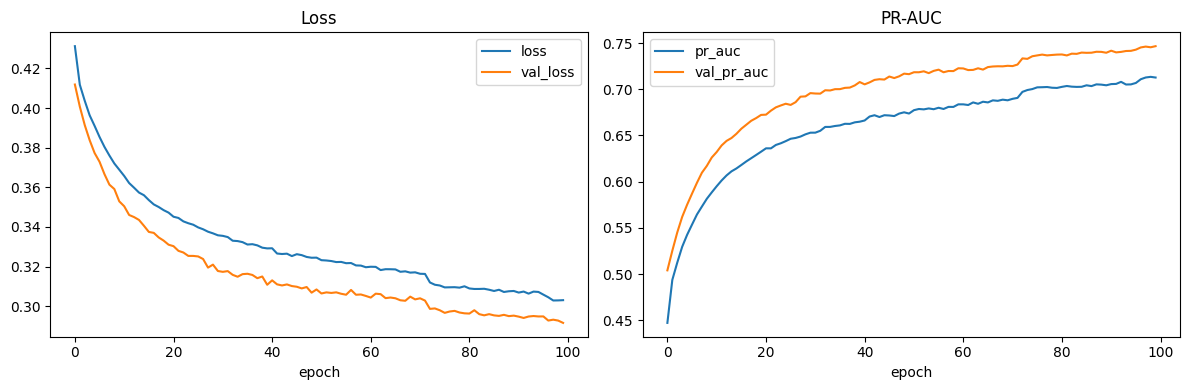

In [8]:
import matplotlib.pyplot as plt

history = pd.read_csv(history_path)
display(history.tail())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history[["loss", "val_loss"]].plot(ax=axes[0], title="Loss")
history[["pr_auc", "val_pr_auc"]].plot(ax=axes[1], title="PR-AUC")
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

In [9]:
predictions = pd.read_csv(predictions_path)
display(predictions.head())

print("예측 파일 크기:", predictions.shape)
print("사고발생 라벨 분포")
display(predictions["사고발생"].value_counts(dropna=False).rename_axis("사고발생").reset_index(name="count"))

print("사고발생확률 요약")
display(predictions["사고발생확률"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T)

,POINT_ID,위도,경도,위험도,사고발생,사고발생확률,사고발생예측
0,1,37.590982,126.992616,0.000,0,0.002192,0
1,8,37.590081,126.991800,0.000,0,0.004074,0
2,9,37.590242,126.991611,0.000,0,0.004723,0
3,25,37.583259,127.000080,0.000,0,0.020163,0
4,29,37.582845,126.999079,37.008,1,0.834957,1


예측 파일 크기: (67600, 7)
사고발생 라벨 분포


,사고발생,count
0,0,54118
1,1,13482


사고발생확률 요약


,count,mean,std,min,50%,75%,90%,95%,99%,max
사고발생확률,67600.0,0.23293,0.269115,0.000004,0.104458,0.375547,0.698547,0.827244,0.942355,0.994106


In [10]:
top_predictions = predictions.sort_values("사고발생확률", ascending=False).head(30)
display(top_predictions[["POINT_ID", "위도", "경도", "위험도", "사고발생", "사고발생확률", "사고발생예측"]])

,POINT_ID,위도,경도,위험도,사고발생,사고발생확률,사고발생예측
13196,87930,37.578240,127.038851,28.848,1,0.994106,1
24152,161433,37.612873,127.030369,12.360,1,0.993879,1
33423,223065,37.589759,126.943327,0.272,1,0.993451,1
43062,287799,37.490469,126.884592,1.700,1,0.993202,1
13254,88376,37.579444,127.043644,3.912,1,0.992825,1
24937,166705,37.612925,127.030223,12.360,1,0.992668,1
13279,88540,37.578949,127.041280,18.732,1,0.992313,1
34555,230762,37.588158,126.944881,190.080,1,0.992171,1
13054,86974,37.583030,127.041336,0.068,1,0.992090,1
24704,165108,37.613563,127.030028,30.072,1,0.991949,1


In [11]:
confusion = pd.crosstab(
    predictions["사고발생"],
    predictions["사고발생예측"],
    rownames=["actual"],
    colnames=["predicted"],
    dropna=False,
)
display(confusion)

predicted,0,1
actual,,
0,50383,3735
1,4644,8838
